# Physics-Informed Neural Networks for Activity Coefficient Prediction

This notebook presents the development of a physics-informed neural network (PINN) to predict activity coefficients using processed experimental data. By embedding thermodynamic constraints directly into the loss function, we incorporate domain knowledge into the model, ensuring thermodynamic consistency while leveraging a data-driven approach.

## Dependencies

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from pathlib import Path
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import MinMaxScaler
from torchmetrics.regression import R2Score

## PINN modeling

### Designing the Neural Network Components

Define the architecture of the neural network

In [2]:
torch.manual_seed(42)


class NeuralNetArchitecture(nn.Module):
    def __init__(self, in_dim: int, out_dim: int) -> None:
        super().__init__()
        self.layer_1 = nn.Linear(in_dim, 64)
        self.layer_2 = nn.Linear(64, 32)
        self.layer_3 = nn.Linear(32, 16)
        self.layer_4 = nn.Linear(16, out_dim)

    def forward(self, x):
        x = F.relu(self.layer_1(x))
        x = F.relu(self.layer_2(x))
        x = F.relu(self.layer_3(x))
        x = self.layer_4(x)

        return x

Implement a custom loss function that enforces thermodynamic consistency by embedding the Gibbs-Duhem equation into the standard MSE loss

In [3]:
def gibbs_duhem_loss(
    y_pred: torch.Tensor, y_true: torch.Tensor, X: torch.Tensor, lambda_gd: float = 1.0
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    # MSE loss
    mse_loss = F.mse_loss(y_pred, y_true, reduction="mean")

    # Calculate ln(gamma)
    ln_gamma1 = y_pred[:, 0]
    ln_gamma2 = y_pred[:, 1]

    # Compute partial derivatives
    dgamma1_dx1 = torch.autograd.grad(
        ln_gamma1,
        X,
        grad_outputs=torch.ones_like(ln_gamma1),
        create_graph=True,
        allow_unused=True,
    )[0][:, 2]

    dgamma2_dx1 = torch.autograd.grad(
        ln_gamma2,
        X,
        grad_outputs=torch.ones_like(ln_gamma2),
        create_graph=True,
        allow_unused=True,
    )[0][:, 2]

    # Compute Gibbs-Duhem term
    x1 = X[:, 2]
    x2 = X[:, 5]

    gibbs_duhem_term = x1 * dgamma1_dx1 + x2 * dgamma2_dx1

    # Scale physics loss
    gd_loss = torch.mean(gibbs_duhem_term**2) * lambda_gd

    # Total loss
    loss = mse_loss + gd_loss

    return loss, mse_loss, gd_loss, gibbs_duhem_term

### Reading the data

Defining the data path conveniently:

In [4]:
DATA_PATH = Path("../data")

Reading the data into a `pandas.DataFrame`:

In [5]:
data = pd.read_csv(DATA_PATH / "processed" / "toy_problem_input_dataset.csv")

data

,r_1,q_1,x_1,r_2,q_2,x_2,T,gamma_1,gamma_2
0,9.9262,8.296,0.00,5.8486,4.936,1.00,398.839,0.102990,0.000000
1,9.9262,8.296,0.01,5.8486,4.936,0.99,399.213,0.098514,0.000020
2,9.9262,8.296,0.02,5.8486,4.936,0.98,399.590,0.094219,0.000080
3,9.9262,8.296,0.03,5.8486,4.936,0.97,399.971,0.090097,0.000180
4,9.9262,8.296,0.04,5.8486,4.936,0.96,400.355,0.086132,0.000320
...,...,...,...,...,...,...,...,...,...
4035,13.9726,11.536,0.96,3.9243,3.668,0.04,509.434,0.000370,0.496548
4036,13.9726,11.536,0.97,3.9243,3.668,0.03,532.267,0.000180,0.453976
4037,13.9726,11.536,0.98,3.9243,3.668,0.02,568.855,0.000060,0.389959
4038,13.9726,11.536,0.99,3.9243,3.668,0.01,600.617,0.000010,0.340720


Remove rows with NaN values:

In [6]:
data.dropna(inplace=True)
data.reset_index(drop=True, inplace=True)

data

,r_1,q_1,x_1,r_2,q_2,x_2,T,gamma_1,gamma_2
0,9.9262,8.296,0.00,5.8486,4.936,1.00,398.839,0.102990,0.000000
1,9.9262,8.296,0.01,5.8486,4.936,0.99,399.213,0.098514,0.000020
2,9.9262,8.296,0.02,5.8486,4.936,0.98,399.590,0.094219,0.000080
3,9.9262,8.296,0.03,5.8486,4.936,0.97,399.971,0.090097,0.000180
4,9.9262,8.296,0.04,5.8486,4.936,0.96,400.355,0.086132,0.000320
...,...,...,...,...,...,...,...,...,...
4031,13.9726,11.536,0.96,3.9243,3.668,0.04,509.434,0.000370,0.496548
4032,13.9726,11.536,0.97,3.9243,3.668,0.03,532.267,0.000180,0.453976
4033,13.9726,11.536,0.98,3.9243,3.668,0.02,568.855,0.000060,0.389959
4034,13.9726,11.536,0.99,3.9243,3.668,0.01,600.617,0.000010,0.340720


### PINN training

Defining the device and splitting the data into training and test sets

In [7]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

features = data.iloc[:, :-2].values
labels = data.iloc[:, -2:].values

X, X_test, y, y_test = train_test_split(
    features, labels, test_size=0.1, random_state=42
)

Defining the cross-validation setup

In [8]:
k_folds = 10
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

Specifying training hyperparameters

In [9]:
num_epochs = 10000
learning_rate = 1e-3
lambda_gd = 1

Executing the cross-validation training loop to evaluate the best selection of hyperparameters

In [10]:
# Combined loss lists
fold_losses = []
val_losses = []
test_losses = []

# For plotting per fold
train_mse_per_fold = []
train_gd_per_fold = []
train_gd_mse_ratio_per_fold = []
val_mse_per_fold = []
val_gd_per_fold = []
val_gd_mse_ratio_per_fold = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"Fold {fold + 1}/{k_folds}")

    # Split data
    X_train_cv, X_val_cv = X[train_idx], X[val_idx]
    y_train_cv, y_val_cv = y[train_idx], y[val_idx]

    # Scale features
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train_cv)
    X_val_scaled = scaler.transform(X_val_cv)
    X_test_scaled = scaler.transform(X_test)

    # Convert to tensors
    X_train_tensor = torch.tensor(
        X_train_scaled, dtype=torch.float32, requires_grad=True
    ).to(device)
    X_val_tensor = torch.tensor(
        X_val_scaled, dtype=torch.float32, requires_grad=True
    ).to(device)
    X_test_tensor = torch.tensor(
        X_test_scaled, dtype=torch.float32, requires_grad=True
    ).to(device)
    y_train_tensor = torch.tensor(y_train_cv, dtype=torch.float32).to(device)
    y_val_tensor = torch.tensor(y_val_cv, dtype=torch.float32).to(device)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

    # Model and optimizer
    input_size = X_train_cv.shape[1]
    output_size = 2
    model = NeuralNetArchitecture(input_size, output_size).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # Track losses for this fold
    train_mse_history = []
    train_gd_history = []
    train_gd_mse_ratio_history = []
    val_mse_history = []
    val_gd_history = []
    val_gd_mse_ratio_history = []

    # Training loop
    for epoch in range(num_epochs):
        model.train()
        outputs = model(X_train_tensor)
        combined_loss = gibbs_duhem_loss(
            outputs, y_train_tensor, X_train_tensor, lambda_gd
        )
        loss = combined_loss[0]
        mse_loss = combined_loss[1]
        gd_loss = combined_loss[2]
        gd_mse_ratio = gd_loss / mse_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Validation step
        val_outputs = model(X_val_tensor)
        val_combined_loss = gibbs_duhem_loss(
            val_outputs, y_val_tensor, X_val_tensor, lambda_gd
        )
        val_loss = val_combined_loss[0]
        val_mse_loss = val_combined_loss[1]
        val_gd_loss = val_combined_loss[2]
        val_gd_mse_ratio = val_gd_loss / val_mse_loss

        # Store per-epoch loss
        train_mse_history.append(mse_loss.item())
        train_gd_history.append(gd_loss.item())
        train_gd_mse_ratio_history.append(gd_mse_ratio.item())
        val_mse_history.append(val_mse_loss.item())
        val_gd_history.append(val_gd_loss.item())
        val_gd_mse_ratio_history.append(val_gd_mse_ratio.item())

        if (epoch + 1) % 20 == 0:
            print(
                f"[Fold {fold + 1} | Epoch {epoch + 1}]: Training loss -> {loss.item():.4f}, Validation loss -> {val_loss.item():.4f}"
            )

    # Store per-fold loss curves
    train_mse_per_fold.append(train_mse_history)
    train_gd_per_fold.append(train_gd_history)
    train_gd_mse_ratio_per_fold.append(train_gd_mse_ratio_history)
    val_mse_per_fold.append(val_mse_history)
    val_gd_per_fold.append(val_gd_history)
    val_gd_mse_ratio_per_fold.append(val_gd_mse_ratio_history)

    # Evaluate test data
    test_outputs = model(X_test_tensor)
    test_combined_loss = gibbs_duhem_loss(
        test_outputs, y_test_tensor, X_test_tensor, lambda_gd
    )
    test_loss = test_combined_loss[0]

    fold_losses.append(loss.item())
    val_losses.append(val_loss.item())
    test_losses.append(test_loss.item())

# Print average losses
print(f"Average training loss across folds: {np.mean(fold_losses):.4f}")
print(f"Average validation loss across folds: {np.mean(val_losses):.4f}")
print(f"Average test loss across folds: {np.mean(test_losses):.4f}")

Fold 1/10
[Fold 1 | Epoch 20]: Training loss -> 0.5300, Validation loss -> 0.4745
[Fold 1 | Epoch 40]: Training loss -> 0.4565, Validation loss -> 0.4018
[Fold 1 | Epoch 60]: Training loss -> 0.3842, Validation loss -> 0.3418
[Fold 1 | Epoch 80]: Training loss -> 0.3352, Validation loss -> 0.2970
[Fold 1 | Epoch 100]: Training loss -> 0.2808, Validation loss -> 0.2512
[Fold 1 | Epoch 120]: Training loss -> 0.2411, Validation loss -> 0.2216
[Fold 1 | Epoch 140]: Training loss -> 0.2131, Validation loss -> 0.1981
[Fold 1 | Epoch 160]: Training loss -> 0.1908, Validation loss -> 0.1785
[Fold 1 | Epoch 180]: Training loss -> 0.1728, Validation loss -> 0.1613
[Fold 1 | Epoch 200]: Training loss -> 0.1586, Validation loss -> 0.1487
[Fold 1 | Epoch 220]: Training loss -> 0.1463, Validation loss -> 0.1370
[Fold 1 | Epoch 240]: Training loss -> 0.1379, Validation loss -> 0.1297
[Fold 1 | Epoch 260]: Training loss -> 0.1313, Validation loss -> 0.1234
[Fold 1 | Epoch 280]: Training loss -> 0.1256

Plot both MSE and Gibbs-Duhem loss throughout the epochs for each cross-validation fold

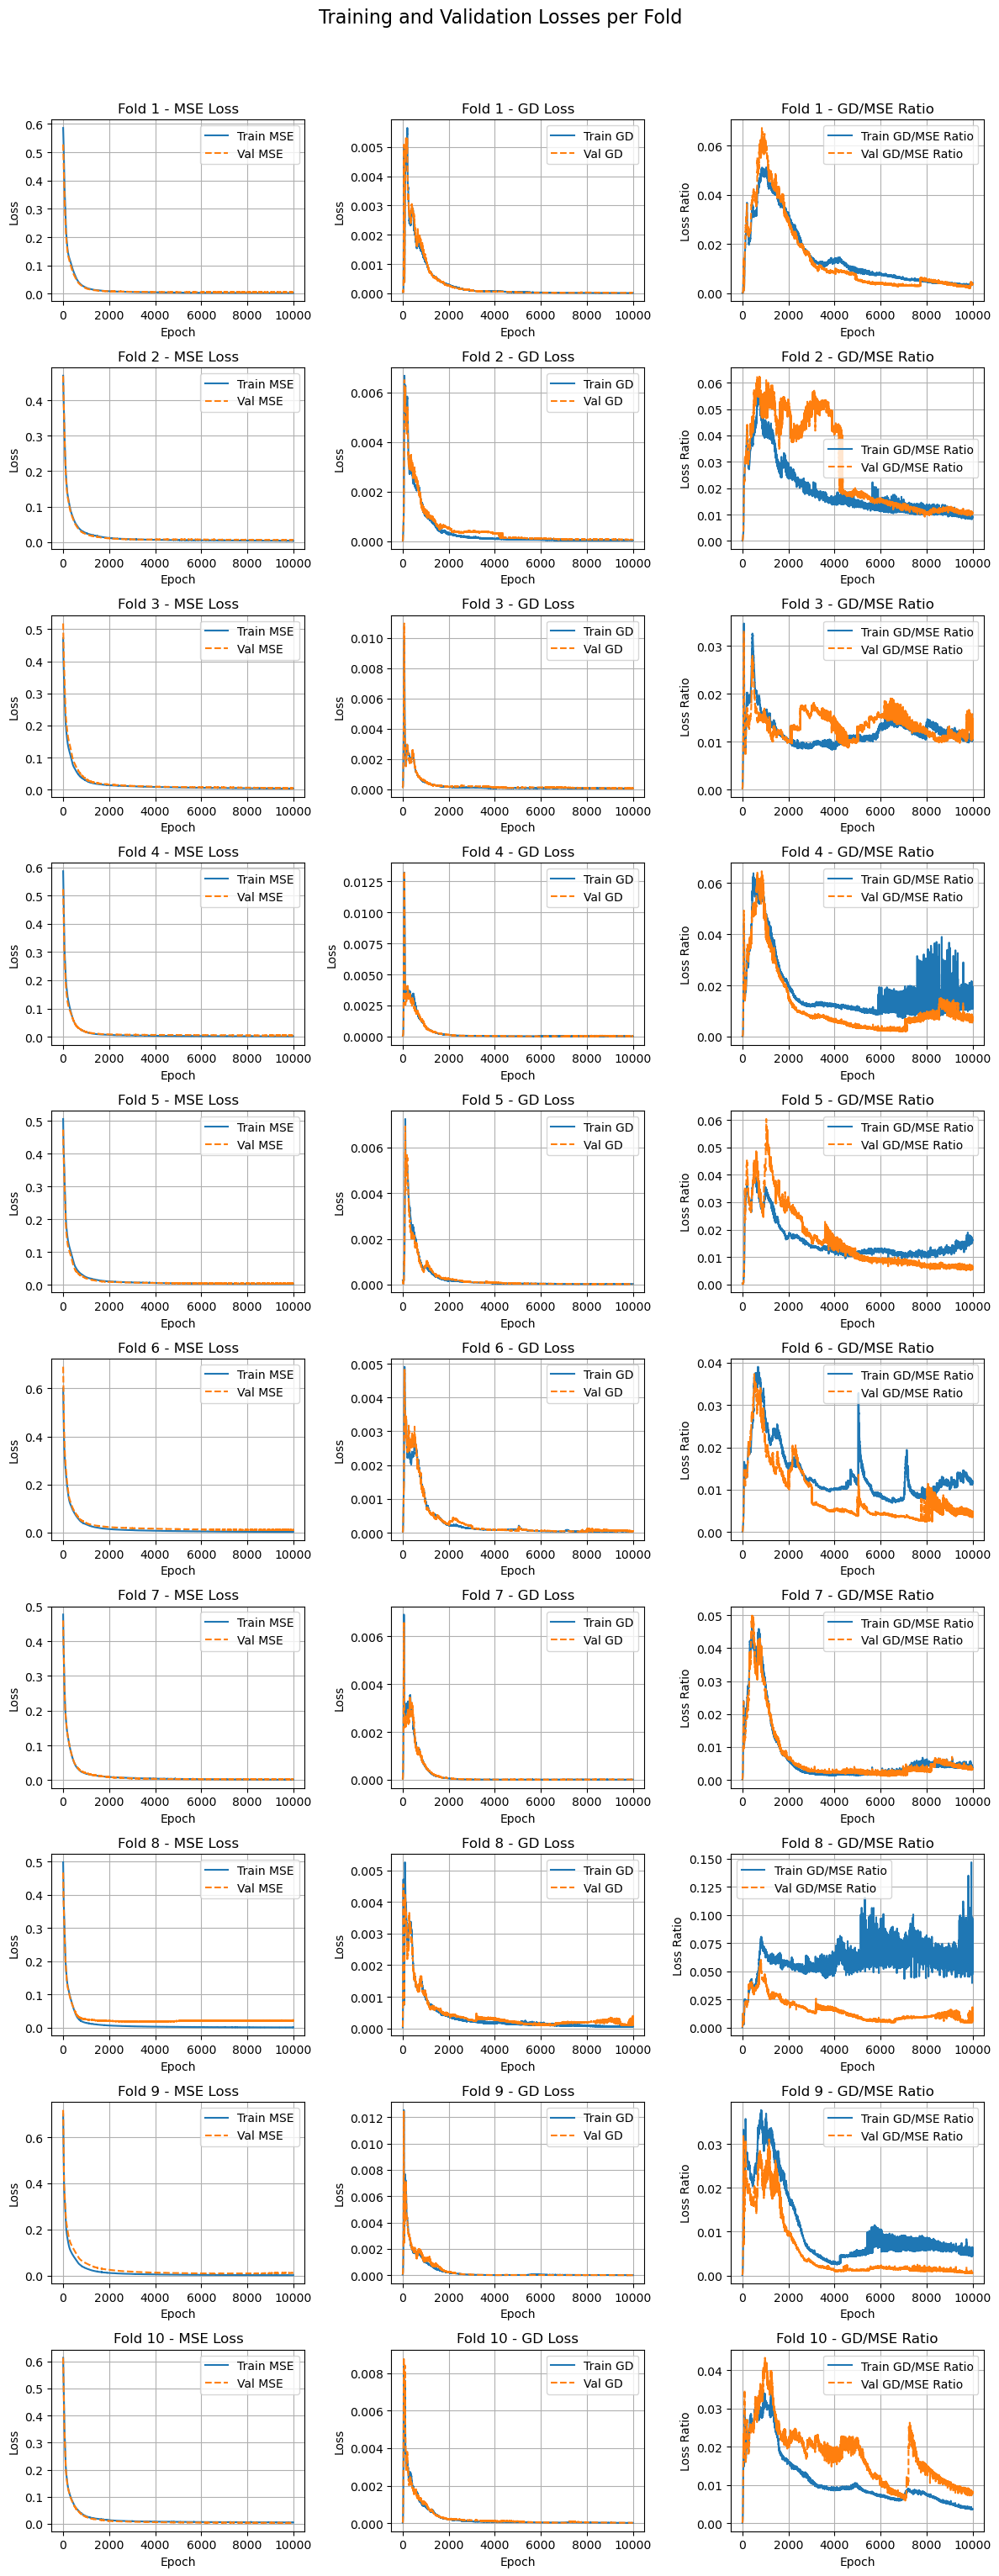

In [11]:
epochs = range(1, num_epochs + 1)

fig, axes = plt.subplots(nrows=k_folds, ncols=3, figsize=(12, 3 * k_folds))
fig.suptitle("Training and Validation Losses per Fold", fontsize=16, y=1.02)

for fold in range(k_folds):
    # MSE plot
    ax_mse = axes[fold, 0]
    ax_mse.plot(epochs, train_mse_per_fold[fold], label="Train MSE", linestyle="-")
    ax_mse.plot(epochs, val_mse_per_fold[fold], label="Val MSE", linestyle="--")
    ax_mse.set_title(f"Fold {fold + 1} - MSE Loss")
    ax_mse.set_xlabel("Epoch")
    ax_mse.set_ylabel("Loss")
    ax_mse.legend()
    ax_mse.grid(True)

    # GD plot
    ax_gd = axes[fold, 1]
    ax_gd.plot(epochs, train_gd_per_fold[fold], label="Train GD", linestyle="-")
    ax_gd.plot(epochs, val_gd_per_fold[fold], label="Val GD", linestyle="--")
    ax_gd.set_title(f"Fold {fold + 1} - GD Loss")
    ax_gd.set_xlabel("Epoch")
    ax_gd.set_ylabel("Loss")
    ax_gd.legend()
    ax_gd.grid(True)

    # GD/MSE ratio plot
    ax_ratio = axes[fold, 2]
    ax_ratio.plot(
        epochs,
        train_gd_mse_ratio_per_fold[fold],
        label="Train GD/MSE Ratio",
        linestyle="-",
    )
    ax_ratio.plot(
        epochs,
        val_gd_mse_ratio_per_fold[fold],
        label="Val GD/MSE Ratio",
        linestyle="--",
    )
    ax_ratio.set_title(f"Fold {fold + 1} - GD/MSE Ratio")
    ax_ratio.set_xlabel("Epoch")
    ax_ratio.set_ylabel("Loss Ratio")
    ax_ratio.legend()
    ax_ratio.grid(True)

plt.tight_layout()
# plt.savefig("images/loss_curves.png", dpi=1200)
plt.show()

### PINN evaluation

Evaluating the model with the selected hyperparameters

In [12]:
X_train, X_val, y_train, y_val = train_test_split(
    features, labels, test_size=0.2, random_state=42
)

# Scale features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert to tensors and move to device
X_train_tensor = torch.tensor(
    X_train_scaled, dtype=torch.float32, requires_grad=True
).to(device)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32, requires_grad=True).to(
    device
)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32, requires_grad=True).to(
    device
)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

# Model and optimizer
input_size = X_train.shape[1]
output_size = 2
model = NeuralNetArchitecture(input_size, output_size).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
for epoch in range(num_epochs):
    model.train()

    # Forward pass
    outputs = model(X_train_tensor)

    # Loss
    combined_loss = gibbs_duhem_loss(outputs, y_train_tensor, X_train_tensor, lambda_gd)
    loss = combined_loss[0]

    # Backward propagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Validation loss
    val_outputs = model(X_val_tensor)
    val_combined_loss = gibbs_duhem_loss(
        val_outputs, y_val_tensor, X_val_tensor, lambda_gd
    )
    val_loss = val_combined_loss[0]

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch + 1}: Training loss -> {loss}")
        print(f"Epoch {epoch + 1}: Validation loss -> {val_loss}")

# Save final model and the scaler
MODEL_PATH = Path("./models")
torch.save(model.state_dict(), MODEL_PATH / "trained_pinn.pt")
joblib.dump(scaler, MODEL_PATH / "scaler.pkl")

# Evaluate test data
test_outputs = model(X_test_tensor)
test_combined_loss = gibbs_duhem_loss(
    test_outputs, y_test_tensor, X_test_tensor, lambda_gd
)
test_loss = test_combined_loss[0]
test_residuals = test_combined_loss[3]

# Print loss for final model
print(f"Training loss: {loss.item(): .4f}")
print(f"Validation loss: {val_loss.item(): .4f}")
print(f"Testing loss: {test_loss.item(): .4f}")

Epoch 20: Training loss -> 0.44950440526008606
Epoch 20: Validation loss -> 0.4035857915878296
Epoch 40: Training loss -> 0.37525713443756104
Epoch 40: Validation loss -> 0.3443472981452942
Epoch 60: Training loss -> 0.3385782539844513
Epoch 60: Validation loss -> 0.30606839060783386
Epoch 80: Training loss -> 0.2862447202205658
Epoch 80: Validation loss -> 0.25660234689712524
Epoch 100: Training loss -> 0.23916369676589966
Epoch 100: Validation loss -> 0.2139923870563507
Epoch 120: Training loss -> 0.21126216650009155
Epoch 120: Validation loss -> 0.18967291712760925
Epoch 140: Training loss -> 0.19215403497219086
Epoch 140: Validation loss -> 0.17306938767433167
Epoch 160: Training loss -> 0.17702551186084747
Epoch 160: Validation loss -> 0.1598520576953888
Epoch 180: Training loss -> 0.16311566531658173
Epoch 180: Validation loss -> 0.14751799404621124
Epoch 200: Training loss -> 0.15044866502285004
Epoch 200: Validation loss -> 0.1364210546016693
Epoch 220: Training loss -> 0.14014

Plotting Predicted vs Experimental Values for $\gamma_1$

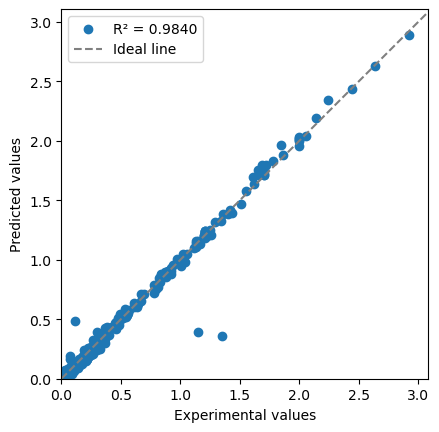

In [13]:
# Calculate R²
r2_metric = R2Score()
r2 = r2_metric(test_outputs[:, 0], y_test_tensor[:, 0]).item()

# Convert tensors to CPU and NumPy for plotting
y_test_np = y_test_tensor[:, 0].cpu().numpy()
preds_np = test_outputs[:, 0].detach().cpu().numpy()

# Plot the scatter plot
plt.scatter(y_test_np, preds_np, label=f"R² = {r2:.4f}")
plt.xlabel("Experimental values")
plt.ylabel("Predicted values")
plt.axis("equal")
plt.axis("square")
plt.xlim([0, plt.xlim()[1]])
plt.ylim([0, plt.ylim()[1]])

# Plot ideal line - Predicted value equal to Experimental
max_val = max(plt.xlim()[1], plt.ylim()[1])
plt.plot(
    [0, max_val],
    [0, max_val],
    linestyle="--",
    color="gray",
    label="Ideal line",
)

plt.legend(loc="upper left")
plt.show()

Plotting Predicted vs Experimental Values for $\gamma_2$

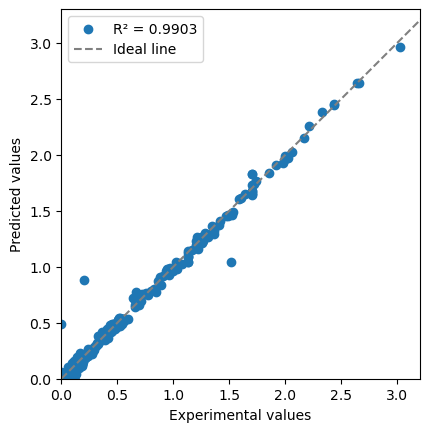

In [14]:
# Calculate R²
r2_metric = R2Score()
r2 = r2_metric(test_outputs[:, 1], y_test_tensor[:, 1]).item()

# Convert tensors to CPU and NumPy for plotting
y_test_np = y_test_tensor[:, 1].cpu().numpy()
preds_np = test_outputs[:, 1].detach().cpu().numpy()

# Plot the scatter plot
plt.scatter(y_test_np, preds_np, label=f"R² = {r2:.4f}")
plt.xlabel("Experimental values")
plt.ylabel("Predicted values")
plt.axis("equal")
plt.axis("square")
plt.xlim([0, plt.xlim()[1]])
plt.ylim([0, plt.ylim()[1]])

# Plot ideal line - Predicted value equal to Experimental
max_val = max(plt.xlim()[1], plt.ylim()[1])
plt.plot(
    [0, max_val],
    [0, max_val],
    linestyle="--",
    color="gray",
    label="Ideal line",
)

plt.legend(loc="upper left")
plt.show()

Plotting Gibbs-Duhem Residual Values

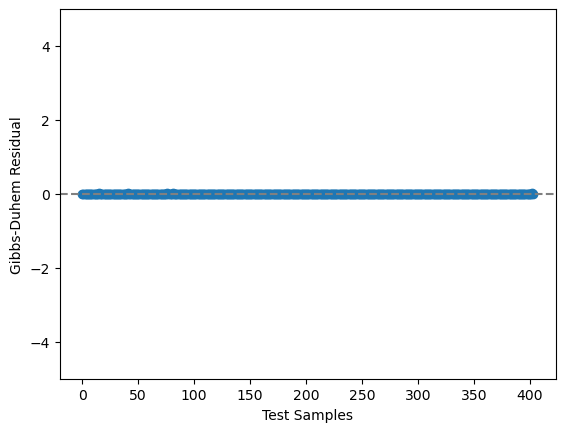

In [15]:
# Convert tensor to NumPy
np_gd_residuals = test_residuals.detach().cpu().numpy()

# Create index for each test sample
test_idxs = np.arange(len(np_gd_residuals))

# Plot residuals against observation index
plt.scatter(test_idxs, np_gd_residuals)
plt.axhline(0, color="gray", linestyle="--")
plt.ylim(-5, 5)
plt.xlabel("Test Samples")
plt.ylabel("Gibbs-Duhem Residual")
plt.show()